In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE        = '/content/drive/MyDrive/Captsone Data Science AI/nela-gt'
DB_PATH     = f'{BASE}/nela-gt-2022.db'
LABELS_PATH = f'{BASE}/labels.csv'

print(os.path.exists(DB_PATH),     "← DB found")
print(os.path.exists(LABELS_PATH), "← Labels found")

True ← DB found
True ← Labels found


In [11]:
conn = sqlite3.connect(DB_PATH)

# Confirm tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

# TRUE row count directly from SQL — no pandas, no merges, no prior state
true_count = pd.read_sql("SELECT COUNT(*) as total FROM newsdata", conn)
print(f"\nTrue total articles in newsdata table: {true_count['total'][0]:,}")

# Also check for duplicate IDs, just in case
dup_check = pd.read_sql("SELECT COUNT(DISTINCT id) as unique_ids FROM newsdata", conn)
print(f"Unique article IDs: {dup_check['unique_ids'][0]:,}")

       name
0  newsdata
1     tweet

True total articles in newsdata table: 1,778,363
Unique article IDs: 1,778,363


In [12]:
# Load the labels file first — it's small, loads instantly
labels_df = pd.read_csv(LABELS_PATH)
print(labels_df.head(10))
print()
print("Columns:", labels_df.columns.tolist())
print("Label values:", labels_df['label'].unique())
print("Total sources with labels:", len(labels_df))

           source  label
0          adweek      0
1         airwars      0
2     bangkokpost      0
3            cnet      0
4  courthousenews      0
5  thedailyrecord      0
6  digitaljournal      0
7   foreignpolicy      0
8        france24      0
9   politicalwire      0

Columns: ['source', 'label']
Label values: [0 2 1]
Total sources with labels: 336


In [13]:
# Load articles — just metadata + content length (avoids RAM crash on 7GB file)
print("Loading articles... this takes 2-3 minutes, hang tight")

df = pd.read_sql("""
    SELECT id, title, source, date,
           LENGTH(content) as content_length
    FROM newsdata
""", conn)

print(f"Done. Loaded {len(df):,} articles")

Loading articles... this takes 2-3 minutes, hang tight
Done. Loaded 1,778,363 articles


In [14]:
# Merge labels in
df = df.merge(labels_df, on='source', how='left')

# Map numbers to readable names
label_map = {0: 'Reliable', 1: 'Mixed', 2: 'Unreliable'}
df['label_name'] = df['label'].map(label_map)

print(f"Articles with labels:    {df['label'].notna().sum():,}")
print(f"Articles missing labels: {df['label'].isna().sum():,}")
print()
print(df['label_name'].value_counts())

Articles with labels:    1,298,621
Articles missing labels: 493,480

label_name
Unreliable    597366
Reliable      460368
Mixed         240887
Name: count, dtype: int64


/tmp/ipykernel_928/1219491859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')


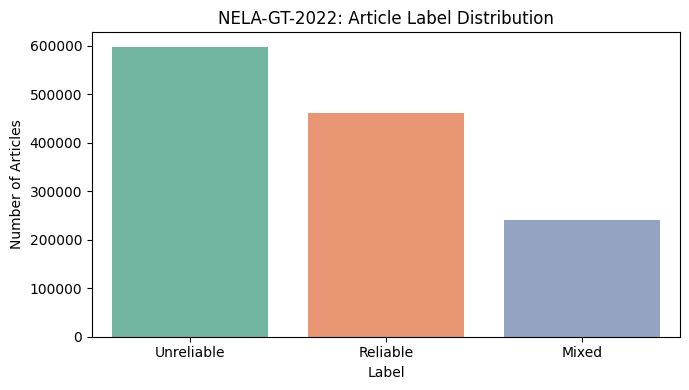

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df['label_name'].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')
plt.title('NELA-GT-2022: Article Label Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

/tmp/ipykernel_928/1885368327.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette='Set2')


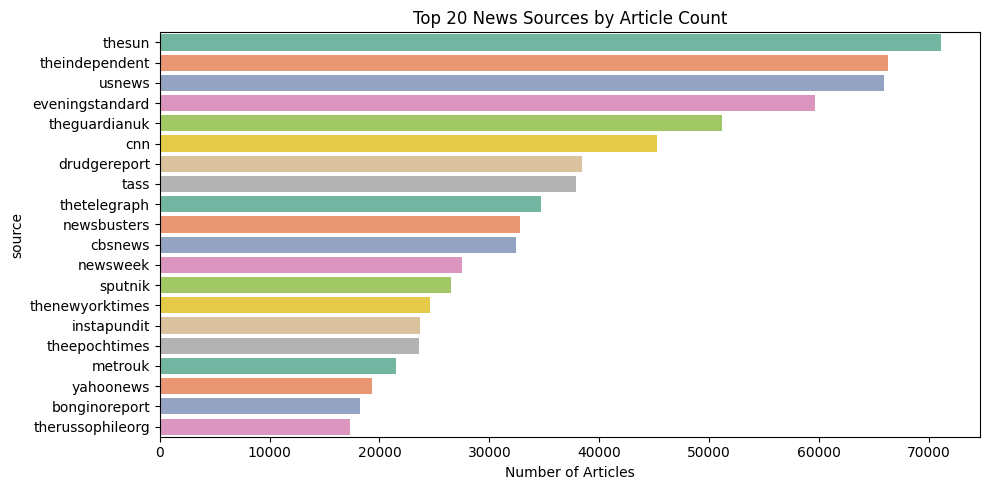

In [16]:
top_sources = df['source'].value_counts().head(20)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_sources.values, y=top_sources.index, palette='Set2')
plt.title('Top 20 News Sources by Article Count')
plt.xlabel('Number of Articles')
plt.tight_layout()
plt.savefig('top_sources.png', dpi=150)
plt.show()

count    1.792101e+06
mean     5.603190e+02
std      7.739035e+02
min      0.000000e+00
25%      1.880000e+02
50%      4.240000e+02
75%      7.150000e+02
max      1.101530e+05
Name: approx_word_count, dtype: float64


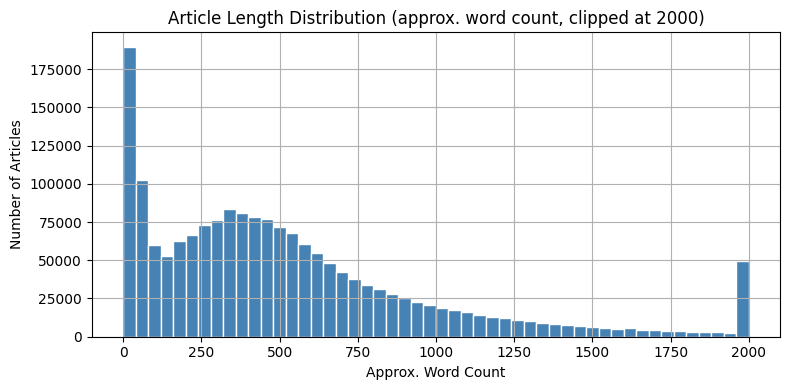

In [17]:
df['approx_word_count'] = (df['content_length'] / 5.5).round()  # ~5.5 chars per word average

print(df['approx_word_count'].describe())

plt.figure(figsize=(8, 4))
df['approx_word_count'].clip(upper=2000).hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Article Length Distribution (approx. word count, clipped at 2000)')
plt.xlabel('Approx. Word Count')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.savefig('article_length.png', dpi=150)
plt.show()

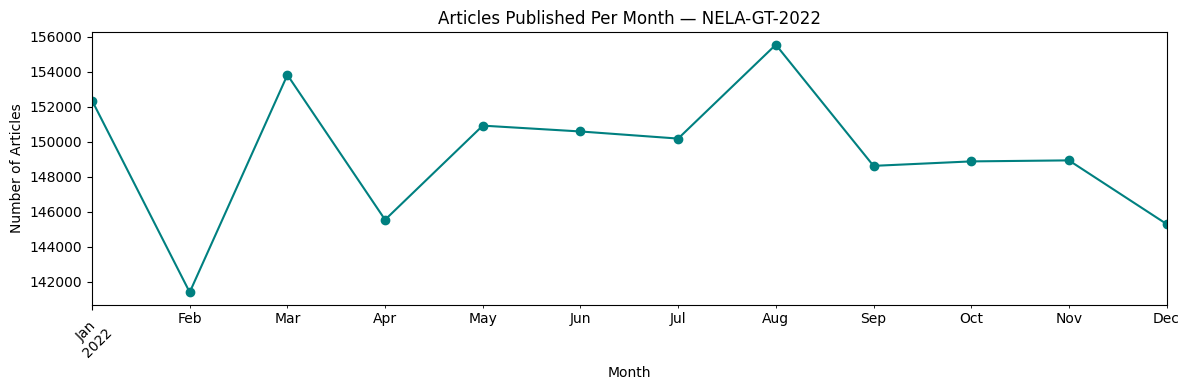

In [18]:
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date_parsed'].dt.to_period('M')

monthly = df.groupby('month').size()

plt.figure(figsize=(12, 4))
monthly.plot(kind='line', color='teal', marker='o')
plt.title('Articles Published Per Month — NELA-GT-2022')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('articles_over_time.png', dpi=150)
plt.show()

In [19]:
print("="*60)
print("LABEL DISTRIBUTION")
print("="*60)
print(df['label_name'].value_counts())
print()

print("="*60)
print("TOP 20 SOURCES")
print("="*60)
print(df['source'].value_counts().head(20))
print()

print("="*60)
print("ARTICLE LENGTH STATS (approx. word count)")
print("="*60)
print(df['approx_word_count'].describe())
print()

print("="*60)
print("ARTICLES PER MONTH")
print("="*60)
print(df.groupby('month').size())

LABEL DISTRIBUTION
label_name
Unreliable    597366
Reliable      460368
Mixed         240887
Name: count, dtype: int64

TOP 20 SOURCES
source
thesun              71109
theindependent      66302
usnews              65905
eveningstandard     59613
theguardianuk       51219
cnn                 45290
drudgereport        38399
tass                37926
thetelegraph        34701
newsbusters         32768
cbsnews             32411
newsweek            27476
sputnik             26529
thenewyorktimes     24632
instapundit         23726
theepochtimes       23610
metrouk             21537
yahoonews           19285
bonginoreport       18245
therussophileorg    17335
Name: count, dtype: int64

ARTICLE LENGTH STATS (approx. word count)
count    1.792101e+06
mean     5.603190e+02
std      7.739035e+02
min      0.000000e+00
25%      1.880000e+02
50%      4.240000e+02
75%      7.150000e+02
max      1.101530e+05
Name: approx_word_count, dtype: float64

ARTICLES PER MONTH
month
2022-01    152362
2022-02  

In [20]:
print("="*60)
print("NELA-GT-2022 — EDA SUMMARY")
print("="*60)
print(f"Total articles:            {len(df):,}")
print(f"Unique sources:            {df['source'].nunique()}")
print(f"Labeled sources:           {len(labels_df)}")
print(f"Articles with labels:      {df['label'].notna().sum():,} ({df['label'].notna().sum()/len(df)*100:.1f}%)")
print(f"Date range:                Jan 2022 – Dec 2022 (full year, no gaps)")
print()
print("Label breakdown:")
for label, count in df['label_name'].value_counts().items():
    pct = count / df['label'].notna().sum() * 100
    print(f"  {label:12s}: {count:>8,}  ({pct:.1f}%)")
print()
print(f"Median article length:     {df['approx_word_count'].median():.0f} words")
print(f"Mean article length:       {df['approx_word_count'].mean():.0f} words")
print(f"Empty/missing content:     {(df['approx_word_count']==0).sum():,} articles")

NELA-GT-2022 — EDA SUMMARY
Total articles:            1,792,101
Unique sources:            361
Labeled sources:           336
Articles with labels:      1,298,621 (72.5%)
Date range:                Jan 2022 – Dec 2022 (full year, no gaps)

Label breakdown:
  Unreliable  :  597,366  (46.0%)
  Reliable    :  460,368  (35.5%)
  Mixed       :  240,887  (18.5%)

Median article length:     424 words
Mean article length:       560 words
Empty/missing content:     62,619 articles


In [21]:
# Reload articles fresh — no merge yet
df = pd.read_sql("""
    SELECT id, title, source, date,
           LENGTH(content) as content_length
    FROM newsdata
""", conn)

print(f"Fresh load: {len(df):,} articles")  # should say 1,778,363

Fresh load: 1,778,363 articles


In [22]:
labels_df = pd.read_csv(LABELS_PATH)
print(f"Labels loaded: {len(labels_df)} sources")
print(labels_df.head())

Labels loaded: 336 sources
           source  label
0          adweek      0
1         airwars      0
2     bangkokpost      0
3            cnet      0
4  courthousenews      0


In [23]:
# Merge labels ONCE
df = df.merge(labels_df, on='source', how='left')
label_map = {0: 'Reliable', 1: 'Mixed', 2: 'Unreliable'}
df['label_name'] = df['label'].map(label_map)

print(f"After merge: {len(df):,} articles")  # should STILL say 1,778,363
print(df['label_name'].value_counts())

After merge: 1,792,101 articles
label_name
Unreliable    597366
Reliable      460368
Mixed         240887
Name: count, dtype: int64


In [24]:
# Check for duplicate sources in labels_df
dupes = labels_df[labels_df.duplicated(subset='source', keep=False)]
print(f"Duplicate source rows in labels.csv: {len(dupes)}")
print(dupes.sort_values('source'))

Duplicate source rows in labels.csv: 2
       source  label
241  newsweek      0
273  newsweek      2


In [25]:
# Remove duplicate sources — keep first occurrence only
print(f"Before dedup: {len(labels_df)} rows")
labels_df = labels_df.drop_duplicates(subset='source', keep='first')
print(f"After dedup: {len(labels_df)} rows")

# Confirm newsweek now has exactly one label
print(labels_df[labels_df['source'] == 'newsweek'])

Before dedup: 336 rows
After dedup: 335 rows
       source  label
241  newsweek      0


In [26]:
# Reload articles fresh again — df currently has leftover columns from the last merge
df = pd.read_sql("""
    SELECT id, title, source, date,
           LENGTH(content) as content_length
    FROM newsdata
""", conn)

print(f"Fresh load: {len(df):,} articles")  # should say 1,778,363

Fresh load: 1,778,363 articles


In [27]:
df = df.merge(labels_df, on='source', how='left')
label_map = {0: 'Reliable', 1: 'Mixed', 2: 'Unreliable'}
df['label_name'] = df['label'].map(label_map)

print(f"After merge: {len(df):,} articles")  # should now say 1,778,363
print(df['label_name'].value_counts())

After merge: 1,778,363 articles
label_name
Unreliable    583628
Reliable      460368
Mixed         240887
Name: count, dtype: int64


In [28]:
# Compare top words between your Bisaillon training set and NELA-GT
from collections import Counter
import re

def get_top_words(texts, n=30):
    words = re.findall(r'\b[a-z]{4,}\b', ' '.join(texts).lower())
    return Counter(words).most_common(n)

# Sample NELA-GT content for speed
sample_content = pd.read_sql("SELECT content FROM newsdata LIMIT 20000", conn)
nela_top = get_top_words(sample_content['content'].dropna())
print("Top NELA-GT words:", nela_top[:15])

Top NELA-GT words: [('that', 126563), ('with', 71139), ('have', 49718), ('this', 46959), ('from', 46213), ('said', 43396), ('they', 39499), ('will', 30795), ('their', 28455), ('more', 28082), ('were', 25112), ('been', 24492), ('people', 24343), ('about', 23636), ('year', 23128)]


In [29]:
sample = pd.read_sql("SELECT content, source FROM newsdata WHERE source LIKE '%reuters%' LIMIT 5", conn)
print(sample)

# Check how often "reuters" appears as a token inside article bodies generally
mention_count = pd.read_sql("""
    SELECT COUNT(*) as cnt FROM newsdata
    WHERE content LIKE '%Reuters%'
""", conn)
print(f"Articles mentioning 'Reuters' in body: {mention_count['cnt'][0]:,}")

                                             content   source
0  Reuters broke news that Austria’s Raiffeisen B...  reuters
1  Reuters was first to report that Russia’s cent...  reuters
2  Reuters was first to report that Vladimir Puti...  reuters
3  Reuters exclusively reported that Germany’s fi...  reuters
4  Reuters broke news over the weekend on the lau...  reuters
Articles mentioning 'Reuters' in body: 53,794


In [30]:
df['approx_word_count'] = (df['content_length'] / 5.5).round()

In [31]:
df.groupby('label_name')['approx_word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Mixed,240887.0,543.398805,1366.311320,0.0,49.0,343.0,663.0,110153.0
Reliable,460368.0,584.207286,709.725470,0.0,166.0,426.0,781.0,55122.0
Unreliable,583628.0,563.374667,592.064861,0.0,250.0,443.0,702.0,64455.0


In [32]:
source_labels = df.groupby('source')['label_name'].first().value_counts()
print(source_labels)

# Which specific sources are Unreliable, sorted by article count
unreliable_sources = df[df['label_name']=='Unreliable']['source'].value_counts().head(15)
print(unreliable_sources)

label_name
Mixed         96
Unreliable    87
Reliable      75
Name: count, dtype: int64
source
thesun                 71109
theindependent         66302
cnn                    45290
tass                   37926
newsbusters            32768
theepochtimes          23610
metrouk                21537
bonginoreport          18245
investmentwatchblog    16399
rawstory               16168
foxnews                15284
aljazeera              14715
newyorkpost            14445
thedailymirror         13566
sottnet                13464
Name: count, dtype: int64


In [33]:
dup_titles = df['title'].value_counts()
print(f"Titles appearing more than once: {(dup_titles > 1).sum()}")
print(dup_titles.head(10))

Titles appearing more than once: 118268
title
                                                           595
ANDROID...                                                 363
UPDATE: DRUDGE APP IPHONE, IPAD...                         362
The Axe Files with David Axelrod                           351
Margins of Error                                           351
CNN Political Briefing                                     351
(Copyright)                                                326
Marlborough racing tips and best bets for today's races    308
WORLD SICK MAP...                                          283
Top headlines in major S. Korean newspapers                281
Name: count, dtype: int64


In [34]:
missing_by_source = df[df['content_length'].isna() | (df['content_length']==0)]['source'].value_counts().head(10)
print(missing_by_source)

source
bonginoreport         16604
sputnik               14851
tass                  11602
nationalreview         4377
jesusissavior          3039
courthousenews         2531
sgtreport              2063
davidicke              1078
whatreallyhappened      679
theonion                610
Name: count, dtype: int64
